In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### imported the merged data sets of scrapped 2025 U.S. and 2025 CA and historical


In [2]:
df_2025_us = pd.read_csv(r"/Users/pardeepwalia/Desktop/untitled folder/2025 dataset us/master_2025_US.csv")
df_2025_ca = pd.read_csv(r"/Users/pardeepwalia/Desktop/untitled folder/2025 datasets/master_2025.csv")
df_historical = pd.read_csv(r"/Users/pardeepwalia/Desktop/untitled folder/Historical data set /jobs_master_2023_2024_wrangled.csv")

### making sure their feature names are exactaly the same


In [3]:
for d in [df_2025_us,df_2025_ca,df_historical]:
    print(f"{d.columns} ")

Index(['title', 'company_name', 'job_location', 'via', 'description',
       'extensions', 'description_tokens', 'job_basket', 'listed_time',
       'location_bucket', 'seniority_level', 'salary_mid_annual', 'SQL',
       'Python', 'Excel', 'Tableau', 'Power BI', 'Cloud', 'Cloud_list',
       'skill_buckets', 'skill_buckets_str', 'skill_details',
       'skill_details_str', 'skills_flat', 'salary_min_annual',
       'salary_max_annual', 'salary_currency', 'comp_type', 'source_file',
       'listed_year'],
      dtype='object') 
Index(['title', 'company_name', 'job_location', 'via', 'description',
       'extensions', 'description_tokens', 'job_basket', 'listed_time',
       'location_bucket', 'seniority_level', 'salary_mid_annual', 'SQL',
       'Python', 'Excel', 'Tableau', 'Power BI', 'Cloud', 'Cloud_list',
       'skill_buckets', 'skill_buckets_str', 'skill_details',
       'skill_details_str', 'skills_flat', 'salary_min_annual',
       'salary_max_annual', 'salary_currency', 'comp_

###  Checking the location bucket for these data sets

In [4]:
df_2025_us['location_bucket'].value_counts()

location_bucket
USA       1393
Remote      79
Name: count, dtype: int64

In [5]:
df_2025_ca['location_bucket'].value_counts()

location_bucket
Canada    1269
Remote     132
Name: count, dtype: int64

In [6]:
df_historical['location_bucket'].value_counts()

location_bucket
Remote           10753
United States     8996
Name: count, dtype: int64

### Normalizing the bucket names


In [7]:
location_map ={
    "USA" :"United States",
    "US": "United States",
    "Canada": "Canada",
    "Remote": "Remote"
}

df_2025_ca['location_bucket'] = df_2025_ca['location_bucket'].replace(location_map)
df_2025_us['location_bucket'] = df_2025_us['location_bucket'].replace(location_map)
df_historical['location_bucket'] = df_historical['location_bucket'].replace(location_map)

### checking propotions


In [8]:
for d in [df_2025_ca,df_2025_us,df_historical]:
    print(f"{d['location_bucket'].value_counts(normalize=True) *100} \n")

location_bucket
Canada    90.578158
Remote     9.421842
Name: proportion, dtype: float64 

location_bucket
United States    94.633152
Remote            5.366848
Name: proportion, dtype: float64 

location_bucket
Remote           54.448326
United States    45.551674
Name: proportion, dtype: float64 



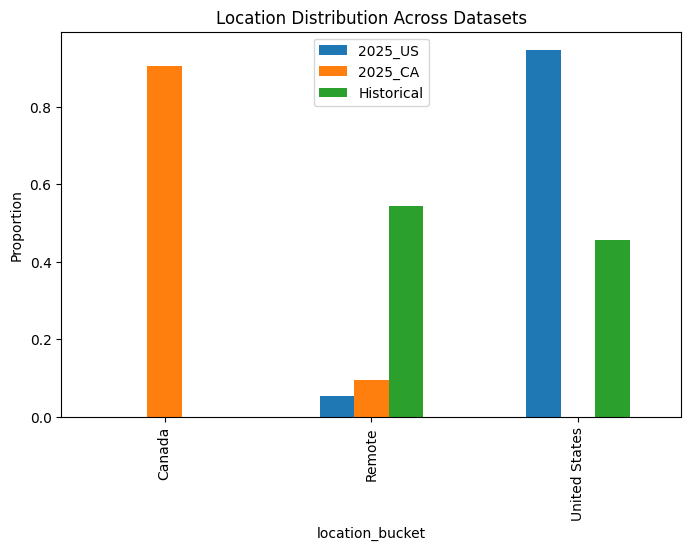

In [9]:
data = {
    "2025_US": df_2025_us['location_bucket'].value_counts(normalize=True),
    "2025_CA": df_2025_ca['location_bucket'].value_counts(normalize=True),
    "Historical": df_historical['location_bucket'].value_counts(normalize=True),
}
pd.DataFrame(data).plot(kind="bar", figsize=(8,5))
plt.title("Location Distribution Across Datasets")
plt.ylabel("Proportion")
plt.show()

### bais in 2023 

In [10]:

df_historical['listed_year'].value_counts()

listed_year
2023    14884
2022     3584
2024     1281
Name: count, dtype: int64

### Merging the data sets together

In [11]:
df_merged  = pd.concat([df_historical,df_2025_ca,df_2025_us], ignore_index=True)

In [12]:
df_merged.shape

(22630, 30)

In [13]:
df_merged['listed_year'].value_counts()

listed_year
2023    14902
2022     3598
2025     2752
2024     1348
2020       12
2019        7
2017        5
2021        4
2013        1
2018        1
Name: count, dtype: int64

### identifying the posted years


In [14]:
df_merged[df_merged['listed_year']<2020]
df_merged['listed_year'].value_counts()

listed_year
2023    14902
2022     3598
2025     2752
2024     1348
2020       12
2019        7
2017        5
2021        4
2013        1
2018        1
Name: count, dtype: int64

### Remove outlier years 

In [15]:

df_merged = df_merged.query("listed_year >2021")

In [16]:
df_merged['listed_year'].value_counts()

listed_year
2023    14902
2022     3598
2025     2752
2024     1348
Name: count, dtype: int64

### Adding Weights to deal with bias in dataset


In [17]:
# Applying weights 
year_counts= df_merged['listed_year'].value_counts().to_dict()

# getting the minimum count  
target_year = min(year_counts.values())

# computing weights for each year
weights = {year : target_year / count for year , count in year_counts.items()}


In [18]:
weights

{2023: 0.09045765669037713,
 2022: 0.3746525847693163,
 2025: 0.4898255813953488,
 2024: 1.0}

### creating new column called Weight

In [19]:

df_merged['weights'] = df_merged['listed_year'].map(weights)

In [20]:
df_merged.sample(10)

,title,company_name,job_location,via,description,extensions,description_tokens,job_basket,listed_time,location_bucket,...,skill_details,skill_details_str,skills_flat,salary_min_annual,salary_max_annual,salary_currency,comp_type,source_file,listed_year,weights
5115,Senior Data Analyst - Digital Marketing - Remote,Progressive,United States,via SimplyHired,Job Number: 205029\n\nJoin Forbes’ 2022 Best E...,"['6 hours ago', 'Full-time', 'Health insurance...","['sql', 'r', 'python']",Data Analytics,2025.0,Remote,...,{},NaN,"['SQL', 'Python']",68100.0,90800.0,USD,salary,gsearch_jobs_2023_q1.csv,2023,0.090458
11130,Supply Chain Master Data Analyst,Double Good,United States,via Jobs Trabajo.org,Double Good creates joy through our product ba...,"['16 hours ago', 'Full-time', 'Health insuranc...",[],Data Analytics,2023.0,United States,...,{},NaN,[],33280.0,33280.0,USD,salary,gsearch_jobs_2023_q3.csv,2023,0.090458
9217,Data Analyst,Providencia Group,Anywhere,via Indeed,TITLE: DATA ANALYST\n\nLOCATION: Nationwide/Re...,"['8 hours ago', 'Work from home', 'Full-time']","['tableau', 'word', 'power_bi', 'spss', 'excel']",Data Analytics,2025.0,Remote,...,{},NaN,"['Excel', 'Tableau', 'Power BI']",NaN,NaN,NaN,salary,gsearch_jobs_2023_q2.csv,2023,0.090458
18724,Data Analyst (Experience in banking domain),Futran Solutions,United States,via LinkedIn,Job Title: Data Analyst (Experience in banking...,"['13 hours ago', 'Full-time', 'No degree menti...",[],Data Analytics,2025.0,United States,...,{},NaN,[],27040.0,27040.0,USD,salary,gsearch_jobs_2022.csv,2022,0.374653
22183,Senior Data Scientists,RSDCGROUP,"Arlington, VA 22209",indeed,Introduction We are seeking highly skilled Sen...,[],[],Data Scientist,2025-08-24 04:33:20+00:00,United States,...,{'Cloud': ['aws']},Cloud:[aws],"['Python', 'Cloud', 'Cloud:aws']",NaN,NaN,USD,NaN,data_science.csv,2025,0.489826
7219,Senior Data Analyst,Piper Companies,Anywhere,via LinkedIn,Piper Companies is looking for a Senior Data A...,"['6 hours ago', 'Work from home', 'Full-time']","['snowflake', 'tableau', 'sql', 'shell', 'pl/s...",Data Analytics,2025.0,Remote,...,{'Cloud': ['snowflake']},Cloud:[snowflake],"['SQL', 'Tableau', 'Power BI', 'Cloud', 'Cloud...",NaN,NaN,NaN,salary,gsearch_jobs_2023_q2.csv,2023,0.090458
19310,Statistical Data Analyst / Data Modeler Contra...,Dice,Anywhere,via LinkedIn,Dice is the leading career destination for tec...,"['57 minutes ago', 'Work from home', 'Full-tim...","['sql', 'word']",Data Analytics,2025.0,Remote,...,{},NaN,"['SQL', 'Python']",NaN,NaN,NaN,contract,gsearch_jobs_2022.csv,2022,0.374653
22520,Sr. Staff Software Engineer,VC5 Consulting,"Houston, TX 77024",indeed,We are seeking a Senior Staff Software Enginee...,[],[],Machine Learning Engineer,2025-08-20 05:00:00+00:00,United States,...,"{'Cloud': ['aws', 'snowflake']}",Cloud:[aws; snowflake],"['SQL', 'Cloud', 'Cloud:aws', 'Cloud:snowflake']",NaN,NaN,USD,NaN,mi_engineer.csv,2025,0.489826
6620,Senior Data Analyst,Humana,"Lenexa, KS",via BeBee,• *Description**\n\nThe Senior Data Analyst co...,"['9 hours ago', 'Full-time']","['tableau', 'python', 'hadoop']",Data Analytics,2025.0,Remote,...,{},NaN,"['SQL', 'Python', 'Tableau']",NaN,NaN,NaN,salary,gsearch_jobs_2023_q2.csv,2023,0.090458
21353,Business Intelligence Analyst,BryceTech,"Alexandria, VA",indeed,Company Description\n BryceTech is a trusted ...,[],[],Business Intelligence Analyst,2025-08-26 05:00:00+00:00,United States,...,{},NaN,"['Excel', 'Tableau', 'Power BI']",NaN,NaN,USD,NaN,bi_analyst.csv,2025,0.489826


## Initiall EDA

In [21]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22600 entries, 0 to 22629
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               22600 non-null  object 
 1   company_name        22588 non-null  object 
 2   job_location        22553 non-null  object 
 3   via                 21902 non-null  object 
 4   description         22600 non-null  object 
 5   extensions          22600 non-null  object 
 6   description_tokens  22600 non-null  object 
 7   job_basket          22600 non-null  object 
 8   listed_time         22403 non-null  object 
 9   location_bucket     22592 non-null  object 
 10  seniority_level     20970 non-null  object 
 11  salary_mid_annual   13136 non-null  float64
 12  SQL                 22600 non-null  bool   
 13  Python              22600 non-null  bool   
 14  Excel               22600 non-null  bool   
 15  Tableau             22600 non-null  bool   
 16  Power BI 

### Percentage of missing data in each feature

In [22]:
df_merged.isna().mean().sort_values(ascending=False)*100

skill_details_str     74.442478
salary_max_annual     41.876106
salary_min_annual     41.876106
salary_mid_annual     41.876106
salary_currency       41.075221
skill_buckets_str     19.491150
comp_type             11.862832
seniority_level        7.212389
via                    3.088496
listed_time            0.871681
job_location           0.207965
company_name           0.053097
location_bucket        0.035398
skill_buckets          0.000000
skills_flat            0.000000
source_file            0.000000
listed_year            0.000000
skill_details          0.000000
title                  0.000000
Tableau                0.000000
Cloud_list             0.000000
Cloud                  0.000000
Power BI               0.000000
Excel                  0.000000
Python                 0.000000
SQL                    0.000000
job_basket             0.000000
description_tokens     0.000000
extensions             0.000000
description            0.000000
weights                0.000000
dtype: f

# Identifying Duplicates

In [23]:

df_merged.duplicated(subset=['title','company_name','job_location','listed_year']).sum()

np.int64(3093)

### Dropping Duplicates

In [24]:
df_merged=df_merged.drop_duplicates(subset=['title','company_name','job_location','listed_year'])

### Categorical checks

##### looking at unique values in skill bucked importatnt for KPI

In [25]:
# Instance of tageted types of skiils
for v in ['SQL','Excel','Python', 'Tableau','Power BI','Cloud']:
    print(f"{v} : {df_merged[v].sum()}")

SQL : 11387
Excel : 6483
Python : 7301
Tableau : 5800
Power BI : 5340
Cloud : 5096


In [26]:
# Location values
df_merged['location_bucket'].value_counts(normalize=True)

location_bucket
Remote           0.481973
United States    0.456331
Canada           0.061695
Name: proportion, dtype: float64

In [27]:
# Title 
df_merged['title'].value_counts()

title
Data Analyst                                                     2298
Senior Data Analyst                                               690
Data Scientist                                                    301
Data Engineer                                                     264
Business Data Analyst                                             213
                                                                 ... 
Teach me Python for data Analytics                                  1
Data Analyst/BI expert needed - Contract to Hire                    1
Data Analyst Expert Needed                                          1
Data scientist to make a statistical analysis in python             1
Systems Engineer - Artificial Intelligence - Machine Learning       1
Name: count, Length: 9748, dtype: int64

### looking for  Salary trends focus on median salary


In [28]:
df_merged['salary_mid_annual'].describe()

count     11078.000000
mean      64018.682848
std       43772.538612
min         120.000000
25%       33280.000000
50%       45760.000000
75%       85000.000000
max      400000.000000
Name: salary_mid_annual, dtype: float64

### Distribution of salary Ranges

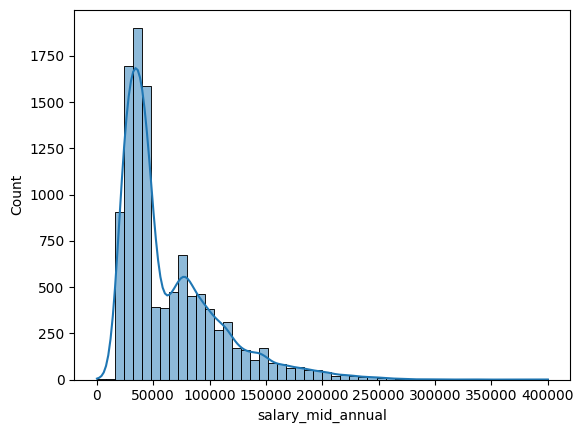

In [29]:
# Shows raw data distribution : Right skwed
sns.histplot(data=df_merged,x='salary_mid_annual',bins=50,kde=True)
plt.show()

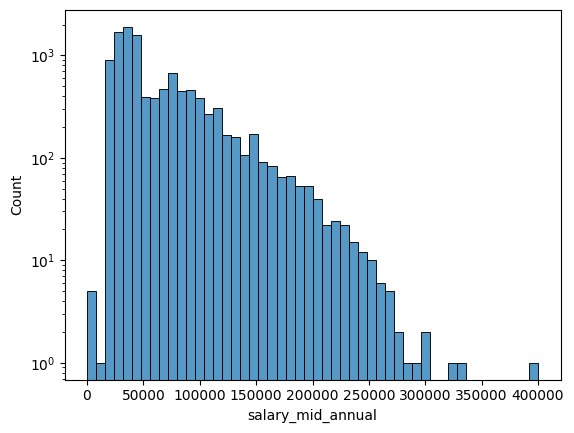

In [30]:
# Applied log scale to see the propotional change insted of absolute change
# helps making the small rare numerical values visible
# how frequency changes across orders of magnitude
sns.histplot(data=df_merged,x='salary_mid_annual',bins=50)
plt.yscale('log')
plt.show()

### seniority level and Salaries

In [31]:
df_merged.columns

Index(['title', 'company_name', 'job_location', 'via', 'description',
       'extensions', 'description_tokens', 'job_basket', 'listed_time',
       'location_bucket', 'seniority_level', 'salary_mid_annual', 'SQL',
       'Python', 'Excel', 'Tableau', 'Power BI', 'Cloud', 'Cloud_list',
       'skill_buckets', 'skill_buckets_str', 'skill_details',
       'skill_details_str', 'skills_flat', 'salary_min_annual',
       'salary_max_annual', 'salary_currency', 'comp_type', 'source_file',
       'listed_year', 'weights'],
      dtype='object')

### using IQR and Q1 and Q3 to cap the salary ammount


In [32]:
q1 = df_merged['salary_mid_annual'].quantile(0.25)
q3 = df_merged['salary_mid_annual'].quantile(0.75)
iqr = q3-q1
print(iqr)
lower_cap = q1-1.5*iqr
upper_cap = q3+1.5*iqr
print(f" q1: {q1} \n q3: {q3}")

print(f" lower cap: {lower_cap} \n upper cap: {upper_cap}")

51720.0
 q1: 33280.0 
 q3: 85000.0
 lower cap: -44300.0 
 upper cap: 162580.0


In [33]:
# using value close to q1 insted of lower cap as it was calculated to be negative.

df_merged = df_merged.query("salary_mid_annual >= 28000")

In [34]:
df_merged[['salary_mid_annual']].describe()

,salary_mid_annual
count,9332.00000
mean,71534.06059
std,43759.61614
min,28000.00000
25%,37440.00000
50%,53640.00000
75%,92700.00000
max,400000.00000


### looking at the source of jobs

In [35]:
df_merged['via'].value_counts()

via
via LinkedIn                      2158
indeed                            1203
via BeBee                         1051
via Trabajo.org                    735
via ZipRecruiter                   672
                                  ... 
via Emprego                          1
via Diversity.com                    1
via General Catalyst Job Board       1
via Camber Creek Job Board           1
via Neb Student                      1
Name: count, Length: 453, dtype: int64

### looking for ai key words

In [36]:

# AI-powered analytics
# 	•	AI driven customer support
# 	•	AI based model
# 	•	AI tools for engineers
# 	•	AI tech or AI technology

pattern = (
    r'\b(ai|artificial intelligence|genai|generative[\s\-]?ai|'
    r'ai[\s/\-]?ml|ml[\s/\-]?ai|ai[\s\-]?(powered|driven|based|tools?|tech(nology)?)?)\b'
)

ai_counts = df_merged['description'].str.contains(pattern,case=False,na=False)


jobs_ai=df_merged[ai_counts]

/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/3733355504.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ai_counts = df_merged['description'].str.contains(pattern,case=False,na=False)


### appearance of AI in job descriptions of Data jobs

In [37]:
jobs_ai['listed_year'].value_counts()

listed_year
2025    498
2023    383
2024    117
2022     69
Name: count, dtype: int64

In [38]:
df_merged['contains_ai'] = ai_counts

### Work type  counts

In [39]:
df_merged[['listed_year','location_bucket']].value_counts()

listed_year  location_bucket
2023         United States      3461
             Remote             2953
2022         United States       749
             Remote              673
2025         United States       672
             Canada              398
2024         United States       229
2025         Remote              100
2024         Remote               91
             Canada                3
Name: count, dtype: int64

In [40]:
df_merged.shape

(9332, 32)

## Exploring Seniority levels

In [41]:
df_merged['seniority_level'].value_counts()

seniority_level
Lead/Principal       2435
Senior               1741
Unspecified          1621
Manager               954
Director+             773
Junior/Entry          375
Mid                   341
Executive             231
Intern                 89
Manager/Director+      55
Junior                 13
Name: count, dtype: int64

### Looking for the Seniority type == "Unspecified"

In [42]:

pattern_snr_lvl = r"""(?ix)
\b(
    jr\.?|junior
  | sr\.?|senior
  | lead | principal | staff
  | manager | mgr\.?
  | director | head | chief
  | vp | svp | evp | vice[ -]?president
  | c(?:eo|to|io|fo|oo)
  | intern(?:ship)? | trainee | apprentice
  | entry(?:[- ]?level)?
  | graduate
  | (?:level|lvl|band|grade)[ -]?[1-9]
  | \b(?:ii|iii|iv|v|vi|vii|i)\b
)\b
"""
unspec_level= df_merged[df_merged['seniority_level']=='Unspecified']['title'].str.contains(pattern_snr_lvl,case=False,na=False,regex=True)

/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/2526144281.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  unspec_level= df_merged[df_merged['seniority_level']=='Unspecified']['title'].str.contains(pattern_snr_lvl,case=False,na=False,regex=True)


### 6 columns with non mid seniority levels

In [43]:
df_merged[df_merged['seniority_level']=='Unspecified'][unspec_level]

,title,company_name,job_location,via,description,extensions,description_tokens,job_basket,listed_time,location_bucket,...,skill_details_str,skills_flat,salary_min_annual,salary_max_annual,salary_currency,comp_type,source_file,listed_year,weights,contains_ai
852,Data Analyst (Level 2),Lockheed Martin Corporation,United States,via Jora,02-Mar-2023\n\nData Analyst (Level 2...\n\nAer...,"['9 hours ago', 'Full-time', 'Health insurance...","['tableau', 'sap', 'python', 'matlab', 'powerp...",Data Analytics,2025.0,Remote,...,NaN,"['SQL', 'Python', 'Tableau']",20800.0,199680.0,USD,salary,gsearch_jobs_2023_q1.csv,2023,0.090458,False
5056,Data Analyst/Dashboard Developer - COO,Tista Science and Technology Corporation,United States,via Recruit.net,Are you a Data Analyst/Dashboard Developer who...,"['4 hours ago', 'Full-time', 'Health insurance...","['tableau', 'sql', 'cognos', 'power_bi']",Data Analytics,2025.0,Remote,...,NaN,"['SQL', 'Tableau', 'Power BI']",55730.0,103500.0,USD,salary,gsearch_jobs_2023_q1.csv,2023,0.090458,False
6537,Data Analytics & Engineering - Data Analyst V ...,Mindlance,Anywhere,via Mindlance - Talentify,Advantages of working with employer:\n\nAs a d...,"['23 hours ago', '104–108 an hour', 'Work from...",['sql'],Data Analytics,2025.0,Remote,...,NaN,['SQL'],47840.0,47840.0,USD,salary,gsearch_jobs_2023_q2.csv,2023,0.090458,False
13602,Data Analyst IV (Healthcare Analytics),Centene Corporation,"Topeka, KS",via Adzuna,You could be the one who changes everything fo...,"['22 hours ago', 'Full-time', 'Health insuranc...","['sql', 'power_bi', 'excel', 'python']",Data Analytics,2023.0,Remote,...,NaN,"['SQL', 'Python', 'Excel', 'Power BI']",45760.0,45760.0,USD,salary,gsearch_jobs_2023_q3.csv,2023,0.090458,False
16067,Data Analyst IV (Remote),Talentify.io,United States,tfy.io,Employer Industry: Recruiting Software\n\nWhy ...,Full-time | YEARLY | BASE_SALARY,[],Data Analytics,2024.0,Remote,...,Cloud:[aws; gcp],"['SQL', 'Python', 'Cloud', 'Cloud:aws', 'Cloud...",120000.0,120000.0,USD,salary,jobs_2024.csv,2024,1.000000,False
16613,Entry data analyst,Dhalite,"Dearing, KS",via Talent.com,"Responsibilities :\n• Interpret data, analyze ...","['15 hours ago', 'Full-time']",[],Data Analytics,2025.0,United States,...,NaN,[],31200.0,31200.0,USD,salary,gsearch_jobs_2022.csv,2022,0.374653,False


### Enriching the seniority level feature that is unspecified with titles with non mid indicators

In [44]:
# chainging the Unspecified to Mid if no levles are found in title
signal_mask = (
    df_merged['title']
    .str.contains(pattern_snr_lvl,case=False,na=False ,regex=True)
)
unspec_mask = df_merged['seniority_level'].eq('Unspecified')


df_merged.loc[unspec_mask & signal_mask,'seniority_level'] = 'Unspecified'
df_merged.loc[unspec_mask & ~signal_mask,'seniority_level'] = 'Mid'

/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/12814182.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_merged['title']


In [45]:
df_merged['seniority_level'].value_counts()

seniority_level
Lead/Principal       2435
Mid                  1956
Senior               1741
Manager               954
Director+             773
Junior/Entry          375
Executive             231
Intern                 89
Manager/Director+      55
Junior                 13
Unspecified             6
Name: count, dtype: int64

### enriching the 6 unspecified with levels

In [46]:
titles = df_merged['title']

rules = [
    (r'\b(?:vp|vice president|chief|cto|cdo|cdao)\b',             'Executive'),
    (r'\b(?:director|head of|sr\.?\s*manager|senior manager)\b',  'Director+'),
    (r'\b(?:manager|lead(?:er)? of|people manager)\b',            'Manager'),
    (r'\b(?:principal|staff|lead|architect)\b',                   'Lead/Principal'),
    (r'\b(?:senior|sr\.?|level\s*iii|iii)\b',                     'Senior'),
    (r'\b(?:mid|intermediate|level\s*ii|ii)\b',                   'Mid'),
    (r'\b(?:junior|jr\.?|entry[-\s]*level|level\s*i|i|associate)\b','Junior/Entry'),
    (r'\b(?:intern|internship|co[-\s]?op|coop)\b',                'Intern'),
]

conds  = [titles.str.contains(rx, regex=True, case=False, na=False) for rx, _ in rules]
labels = [lab for _, lab in rules]

# Predict everywhere, defaulting to "Mid" (not "Unspecified")
predicted = np.select(conds, labels, default="Mid")

unspec_mask = df_merged['seniority_level'].eq('Unspecified')
df_merged.loc[unspec_mask, 'seniority_level'] = predicted[unspec_mask]

In [47]:
df_merged['seniority_level'].value_counts()

seniority_level
Lead/Principal       2435
Mid                  1962
Senior               1741
Manager               954
Director+             773
Junior/Entry          375
Executive             231
Intern                 89
Manager/Director+      55
Junior                 13
Name: count, dtype: int64

### Feature Egineering a new stream line Seniority bucket

In [48]:
mapping = {
    "Intern": "Entry",
    "Junior": "Entry",
    "Junior/Entry": "Entry",
    "Mid": "Mid",
    "Senior": "Senior",
    "Lead/Principal": "Senior",
    "Manager": "Management",
    "Manager/Director+": "Management",
    "Director+": "Executive",
    "Executive": "Executive"
}

df_merged['seniority_group'] = df_merged['seniority_level'].map(mapping)

In [49]:
df_merged['seniority_group'].value_counts()

seniority_group
Senior        4176
Mid           1962
Management    1009
Executive     1004
Entry          477
Name: count, dtype: int64

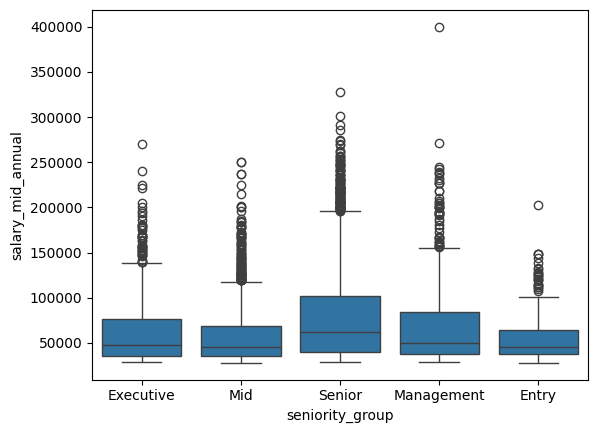

In [50]:
# box plot 
sns.boxplot(data=df_merged, x='seniority_group', y='salary_mid_annual')
# plt.yscale('log')
plt.show()

### Remote Trend thorugh the years

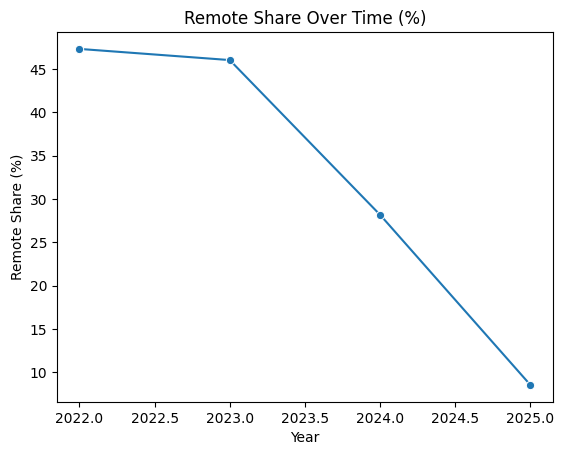

In [51]:
remote_trend = (
    df_merged.assign(is_remote = df_merged['location_bucket'].eq('Remote'))
    .groupby('listed_year')['is_remote']
    .mean()
    .mul(100)
)
remote_trend_df = remote_trend.reset_index(name='remote_share')
sns.lineplot(
    data=remote_trend_df,
    x='listed_year', y='remote_share',
    marker='o'
)

plt.title("Remote Share Over Time (%)")
plt.ylabel("Remote Share (%)")
plt.xlabel("Year")
plt.show()

### Ai buzzwords in job description

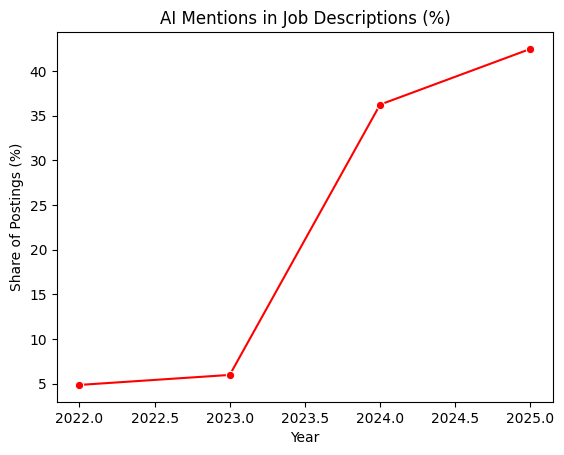

In [52]:
ai_trend = (
    df_merged.groupby('listed_year')['contains_ai']
    .mean()
    .mul(100)
)
# Turn into DataFrame
ai_trend_df = ai_trend.reset_index(name='ai_share')

# Plot with seaborn
sns.lineplot(
    data=ai_trend_df,
    x='listed_year', y='ai_share',
    marker='o', color='red'
)

plt.title("AI Mentions in Job Descriptions (%)")
plt.ylabel("Share of Postings (%)")
plt.xlabel("Year")
plt.show()

### Skils demand over years

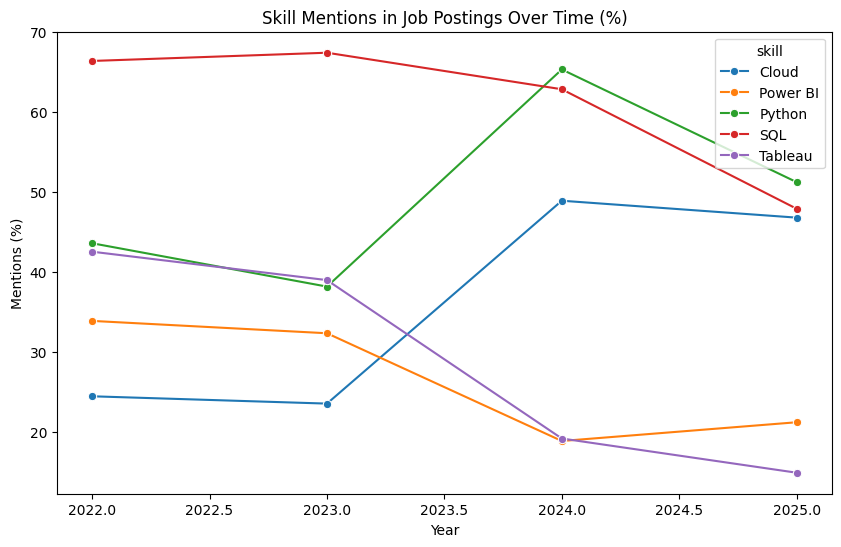

In [53]:
skills = ['SQL','Python','Tableau','Power BI','Cloud']
skill_trends = (
    df_merged.melt(id_vars=['listed_year'], 
                   value_vars=[f'{s}' for s in skills], 
                   var_name='skill', value_name='present')
    .groupby(['listed_year','skill'])['present'].mean().reset_index()
)
skill_trends['present'] *= 100

plt.figure(figsize=(10,6))
sns.lineplot(data=skill_trends, x='listed_year', y='present', 
             hue='skill', marker='o')
plt.title("Skill Mentions in Job Postings Over Time (%)")
plt.xlabel("Year")
plt.ylabel("Mentions (%)")
plt.show()

### Initial EDA Completed

## KPIs Focus

**Remote Work Trends**

    - Share of Remote vs Onsite (2022 → 2025).

    - Role-level view (Analyst vs Scientist vs Engineer).

#### Pre computed Weight did not work becuase isremote is boolean and give 1 for each year

In [54]:
# Adding isremote flag - Remote, anywhere, etc
df_merged['isremote'] = df_merged['location_bucket'].str.contains(r"\bremote\b|\banywhere\b",case=False,na=False)

# using weight columns
remote_YoY = ( df_merged.groupby('listed_year')
              .apply(lambda x: np.average(x['isremote'],weights=x['weights']))
              .reset_index(name='remote_share')
              )
remote_YoY['remote_share'] = (remote_YoY['remote_share']*100).round(1)
remote_YoY


/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/713526176.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  remote_YoY = ( df_merged.groupby('listed_year')


,listed_year,remote_share
0,2022,47.3
1,2023,46.0
2,2024,28.2
3,2025,8.5


In [55]:
df_merged.groupby('listed_year')['weights'].nunique()

listed_year
2022    1
2023    1
2024    1
2025    1
Name: weights, dtype: int64

### Reason for choosing Weight insted of sampling
	•	Preserves the full dataset (no throwing away data).
	•	Flexible (you can design weights by source, year, or country).

### Effective Weighing technique

In [56]:
df_merged.sample(2)

,title,company_name,job_location,via,description,extensions,description_tokens,job_basket,listed_time,location_bucket,...,salary_min_annual,salary_max_annual,salary_currency,comp_type,source_file,listed_year,weights,contains_ai,seniority_group,isremote
5683,REMOTE / HYBRID - Healthcare Data Analyst (HEDIS),SpectraMedix,"Kansas City, MO",via Trabajo.org,SpectraMedix: We provide actionable insights t...,"['22 hours ago', 'Full-time']","['tableau', 'sql', 'python']",Data Analytics,2025.0,United States,...,45760.0,45760.0,USD,salary,gsearch_jobs_2023_q1.csv,2023,0.090458,False,Mid,False
5487,Data Analyst,Fidelity Investments,United States,via Trabajo.org,Job Description:\n\nThe Role...\n\nAre you pas...,"['15 hours ago', 'Full-time', 'No degree menti...","['snowflake', 'python', 'sql']",Data Analytics,2025.0,United States,...,31200.0,31200.0,USD,salary,gsearch_jobs_2023_q1.csv,2023,0.090458,False,Senior,False


In [57]:
# recomputed weight
# 1) Count per source within year
size_by_src = (df_merged
               .groupby(['listed_year','source_file'])
               .size()
               .rename('n')
               .reset_index())

# 2) Post-stratification weight: each source contributes equally in a year
#    weight for a row = 1 / (count from its source in that year)
w_map = (size_by_src
         .assign(w = lambda d: 1.0 / d['n'])
         .set_index(['listed_year','source_file'])['w'])

df_merged['effective_weight'] = df_merged.set_index(['listed_year','source_file']) \
                                  .index.map(w_map)

# sanity: weights should now vary within each year
df_merged.groupby('listed_year')['effective_weight'].nunique()

remote_yoy_w = (df_merged
    .groupby('listed_year')
    .apply(lambda g: np.average(g['isremote'], weights=g['effective_weight']))
    .reset_index(name='remote_share_w'))

remote_yoy_w['remote_share_w'] = (remote_yoy_w['remote_share_w']*100).round(1)
remote_yoy_w


/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/1520836905.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  remote_yoy_w = (df_merged


,listed_year,remote_share_w
0,2022,23.7
1,2023,27.5
2,2024,15.0
3,2025,10.0


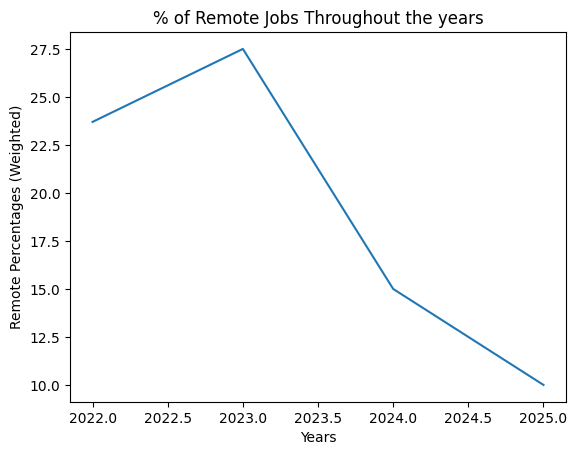

In [58]:
sns.lineplot(data=remote_yoy_w, x='listed_year',y='remote_share_w')
plt.title('% of Remote Jobs Throughout the years')
plt.ylabel('Remote Percentages (Weighted)')
plt.xlabel('Years')
plt.show()

### Fixing job basket

In [59]:
df_merged['job_basket'].value_counts()

job_basket
Data Analytics                   7232
Business Intelligence Analyst     470
Data Engineer                     419
Data Science                      328
Machine Learning Engineer         260
Data Analyst                      245
Data Scientist                    213
Data Architect                    165
Name: count, dtype: int64

In [60]:
map_job_basked = {
    'Data Analytics': 'Data Analyst',
    'Data Science':'Data Scientist',
    'Business Intelligence Analyst' :'BI Analyst',
    'Machine Learning Engineer': 'ML Engineer'
}
df_merged['job_basket'] = df_merged['job_basket'].replace(map_job_basked)

In [61]:
df_merged['job_basket'].value_counts()

job_basket
Data Analyst      7477
Data Scientist     541
BI Analyst         470
Data Engineer      419
ML Engineer        260
Data Architect     165
Name: count, dtype: int64

### Remote by Role

In [62]:
remote_role = (
    df_merged.groupby(['listed_year','job_basket'])
    .apply(lambda g: np.average(g['isremote'], weights=g['effective_weight']))
    .reset_index(name='remote_by_job')
)
remote_role['remote_by_job'] = (remote_role['remote_by_job']*100).round(1)

/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/1367622351.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_merged.groupby(['listed_year','job_basket'])


In [63]:
# data frame year ascending, then followed by decendig remote jobs
remote_role.sort_values(['listed_year','remote_by_job'],ascending=[True,False])

,listed_year,job_basket,remote_by_job
5,2022,ML Engineer,100.0
0,2022,BI Analyst,82.0
3,2022,Data Engineer,75.0
4,2022,Data Scientist,54.1
1,2022,Data Analyst,45.3
2,2022,Data Architect,0.0
9,2023,Data Scientist,62.6
8,2023,Data Engineer,60.3
7,2023,Data Analyst,44.8
6,2023,BI Analyst,5.0


### line plot to show the difference

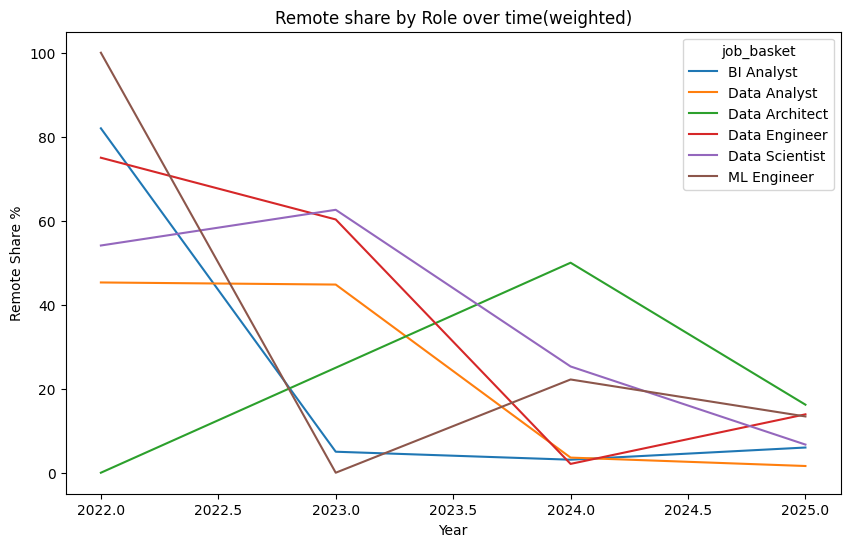

In [64]:
plt.figure(figsize=(10,6))
sns.lineplot(data=remote_role,x='listed_year',y='remote_by_job',hue='job_basket',markers='o')

plt.title("Remote share by Role over time(weighted)")
plt.ylabel('Remote Share %')
plt.xlabel('Year')
plt.show()

In [65]:
# sanity check for jobs with year, job category and location  
# df_merged.query("(listed_year == 2022) & job_basket == 'ML Engineer' ")[['job_basket','location_bucket']]

df_merged[['listed_year','job_basket','location_bucket']].value_counts().sort_index(ascending=True)

listed_year  job_basket      location_bucket
2022         BI Analyst      Remote               50
                             United States        11
             Data Analyst    Remote              593
                             United States       717
             Data Architect  United States         1
             Data Engineer   Remote                9
                             United States         3
             Data Scientist  Remote               20
                             United States        17
             ML Engineer     Remote                1
2023         BI Analyst      Remote              118
                             United States       126
             Data Analyst    Remote             2639
                             United States      3211
             Data Engineer   Remote               62
                             United States        39
             Data Scientist  Remote              134
                             United States        80
 

### ML Engineer and BI analyst in 2022 were very few in this dataset hence the initial percentage


In [66]:
# Resuabe code to calc weigth of each feature for KIPS
def weighted_mean (df: pd.DataFrame,feat:str):
    return  (np.average(df[feat], weights=df['effective_weight']))
 

### KPI 1 dataframes


In [67]:
# #KPI 1 
# remote_yoy_w
# remote_role

## KPI2 Role Demandas

### YoY growth in posting per role

In [68]:
# directly computing the weighted count of postings.
def weighted_sum(g):
    """Weighted count = sum of effective weights in a group."""
    return g['effective_weight'].sum()


In [69]:
growth_role_yoy = (df_merged.groupby(['listed_year','job_basket'],as_index=False)
                   .apply(weighted_sum)
                   .rename(columns={None:'weighted_posts'})
)

/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/1688487005.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  growth_role_yoy = (df_merged.groupby(['listed_year','job_basket'],as_index=False)


In [70]:
# Addig the weights of each weights that was sumed earlier per year per job basket
# Grouping by year and basket then summing upthe weights
# then calculating the % share of each job basket per year
growth_role_yoy['year_total'] = growth_role_yoy.groupby('listed_year')['weighted_posts'].transform('sum')
growth_role_yoy['share_in_year_%'] = (growth_role_yoy['weighted_posts']/growth_role_yoy['year_total']*100).round(1)

### Plot Role share over time (weighted)

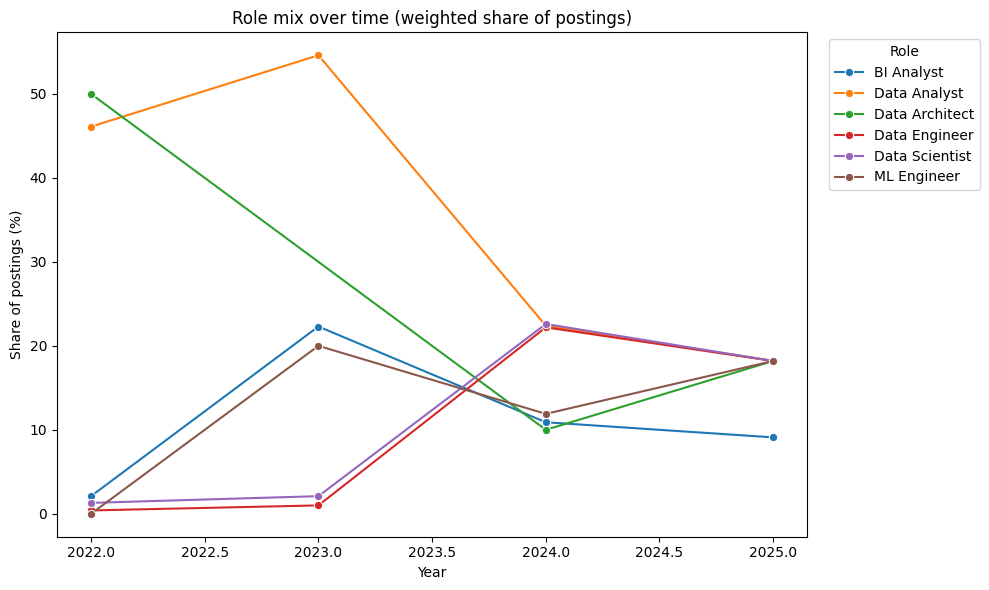

In [71]:
plt.figure(figsize=(10,6))
sns.lineplot(data=growth_role_yoy, x='listed_year', y='share_in_year_%', hue='job_basket', marker='o')
plt.title('Role mix over time (weighted share of postings)')
plt.xlabel('Year'); plt.ylabel('Share of postings (%)')
plt.legend(title='Role', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

### YoY growth in postings per role (weighted)

In [72]:
# YoY % change by role
growth_role_yoy = growth_role_yoy.sort_values(['job_basket','listed_year'])
growth_role_yoy['yoy_growth_%'] = (
    growth_role_yoy.groupby('job_basket')['weighted_posts']
            .pct_change()
            .mul(100).round(1)
)

# fastest up / down in the most recent year vs the year before
latest = growth_role_yoy['listed_year'].max()
last_two = growth_role_yoy.query('listed_year in [@latest-1, @latest]').copy()

wide = (
    last_two
    .pivot(index='job_basket', columns='listed_year', values='weighted_posts')
    .rename_axis(None, axis=1)
)

wide['growth_%'] = ((wide[latest] - wide[latest-1]) / wide[latest-1] * 100).round(1)
top_gainers = wide.sort_values('growth_%', ascending=False).head(5)
top_decliners = wide.sort_values('growth_%', ascending=True).head(5)

print('Top gainers (latest YoY):')
display(top_gainers[['growth_%']])

print('Top decliners (latest YoY):')
display(top_decliners[['growth_%']])

Top gainers (latest YoY):


,growth_%
job_basket,
Data Architect,100.0
ML Engineer,68.3
BI Analyst,-8.6
Data Engineer,-9.7
Data Analyst,-10.8


Top decliners (latest YoY):


,growth_%
job_basket,
Data Scientist,-11.5
Data Analyst,-10.8
Data Engineer,-9.7
BI Analyst,-8.6
ML Engineer,68.3


### Plot Latest YoY growth bar chart

/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/2227539731.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


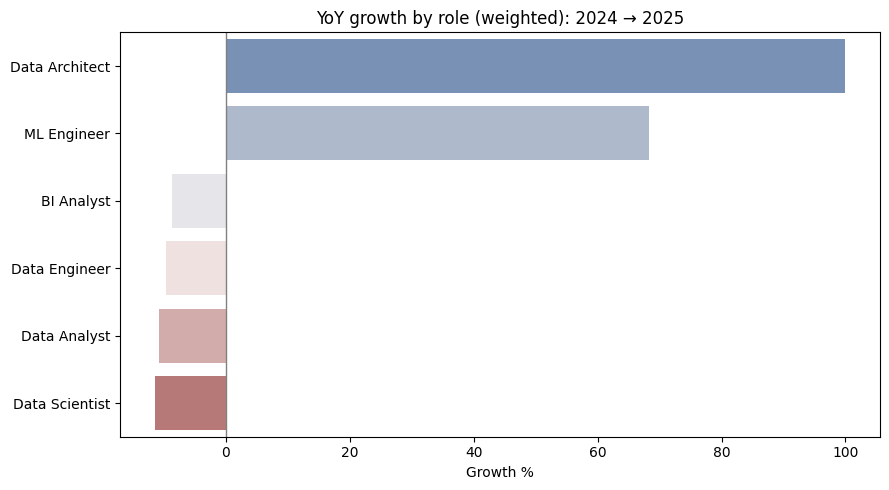

In [73]:
plt.figure(figsize=(9,5))
sns.barplot(
    data=wide.reset_index().sort_values('growth_%', ascending=False),
    x='growth_%', y='job_basket', palette='vlag'
)
plt.axvline(0, color='gray', lw=1)
plt.title(f'YoY growth by role (weighted): {latest-1} → {latest}')
plt.xlabel('Growth %'); plt.ylabel('')
plt.tight_layout(); plt.show()

### CAGR per role

In [74]:
growth_role_yoy

# start and end years
s_year ,e_year = 2022,2025
n_years = e_year-s_year

# pivoting to create values side by side
role_ranges = growth_role_yoy.pivot_table(index='job_basket',columns='listed_year',values='weighted_posts')
role_ranges=role_ranges.fillna(0.00)

In [75]:
# computing CAGR
role_ranges['CAGR_%'] = (
    (role_ranges[e_year] / role_ranges[s_year]) ** (1/n_years) - 1
).mul(100).round(2)

In [76]:
role_ranges

listed_year,2022,2023,2024,2025,CAGR_%
job_basket,,,,,
BI Analyst,0.042928,1.113502,1.094276,1.0,185.60
Data Analyst,0.921886,2.729344,2.242424,2.0,29.45
Data Architect,1.000000,0.000000,1.000000,2.0,25.99
Data Engineer,0.008445,0.051420,2.215488,2.0,518.70
Data Scientist,0.026038,0.104494,2.259259,2.0,325.08
ML Engineer,0.000704,1.001240,1.188552,2.0,1316.47


### for 2023 there was no data architecht posting

In [77]:
df_merged.query('(listed_year == 2023) & job_basket == "Data Architect"')

,title,company_name,job_location,via,description,extensions,description_tokens,job_basket,listed_time,location_bucket,...,salary_max_annual,salary_currency,comp_type,source_file,listed_year,weights,contains_ai,seniority_group,isremote,effective_weight


In [78]:
df_merged.query('(listed_year == 2023)')['title'].str.contains(r'\bData Architect\b',case=False,na=False).sum()

np.int64(0)

### CAGR plot

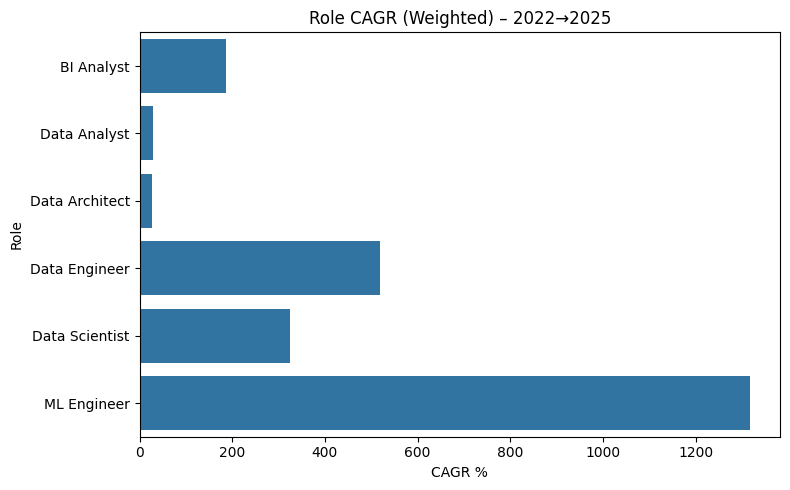

In [79]:
plot_df = role_ranges.reset_index().dropna(subset=['CAGR_%'])
plt.figure(figsize=(8,5))
sns.barplot(data=plot_df, x='CAGR_%', y='job_basket', order=plot_df['job_basket'])
plt.title('Role CAGR (Weighted) – 2022→2025')
plt.xlabel('CAGR %')
plt.ylabel('Role')
plt.tight_layout()
plt.show()

notes:

	ML enginner spike in % ,weight is 2.0 for 2025 but in 2020 it was 0.000704 due to small size of that year
	• ML Engineer shows the fastest compounded growth from 2022–2025, but from a very small base in 2022; 2025 weighted volume = X.”

	•	“Data Engineer / Data Scientist show strong sustained growth with higher 2025 volumes.”

	•	“Data Architect had no postings in 2023; CAGR uses start/end years and remains defined, but we flag the missing year.”

### Normalizing the weights Values

In [80]:
role_index = role_ranges.copy()
base_year = 2022

# normalize to index (base year = 100)
role_index = (role_index
              .div(role_index[base_year], axis=0)
              .mul(100)
              .round(1))

# Keep CAGR_% column for reference
role_index['CAGR_%'] = role_ranges['CAGR_%']

role_index


listed_year,2022,2023,2024,2025,CAGR_%
job_basket,,,,,
BI Analyst,100.0,2593.9,2549.1,2329.5,185.60
Data Analyst,100.0,296.1,243.2,216.9,29.45
Data Architect,100.0,0.0,100.0,200.0,25.99
Data Engineer,100.0,608.9,26235.1,23683.3,518.70
Data Scientist,100.0,401.3,8676.8,7681.1,325.08
ML Engineer,100.0,142276.3,168893.3,284200.0,1316.47


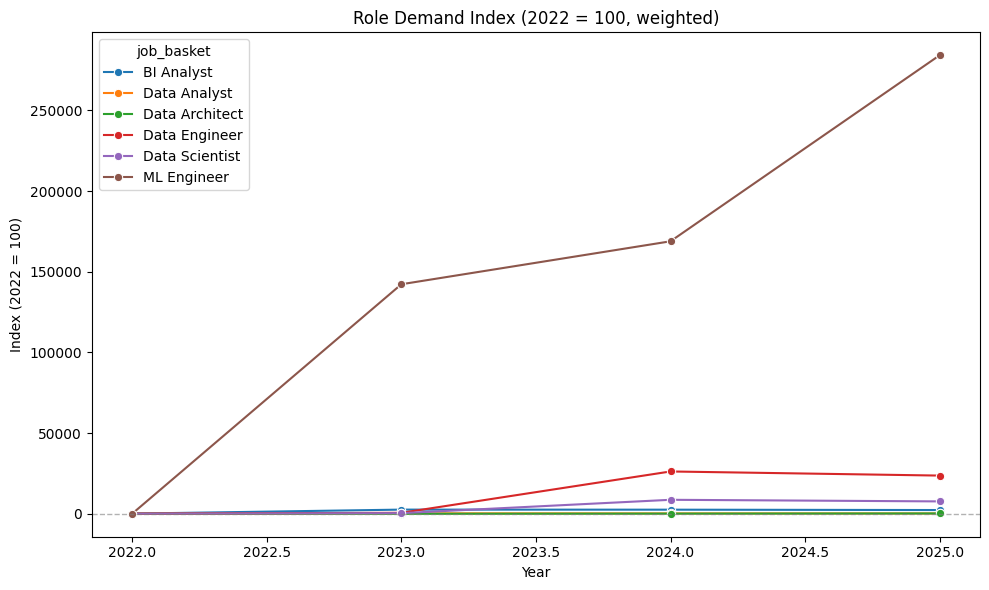

In [81]:
# Long-form for plotting (drop the CAGR column)
idx_long = (role_index
            .drop(columns=['CAGR_%'], errors='ignore')
            .reset_index()                       # brings job_basket out of index
            .melt(id_vars='job_basket',
                  var_name='year', value_name='index_value'))

# Ensure year is numeric for a proper axis
idx_long['year'] = idx_long['year'].astype(int)

plt.figure(figsize=(10,6))
sns.lineplot(data=idx_long, x='year', y='index_value',
             hue='job_basket', marker='o')
plt.axhline(100, color='gray', linestyle='--', linewidth=1, alpha=0.6)  # base line
plt.title('Role Demand Index (2022 = 100, weighted)')
plt.xlabel('Year'); plt.ylabel('Index (2022 = 100)')
plt.tight_layout()
plt.show()

I normalized each role’s weighted postings so 2022 = 100. This allows comparison of relative growth trajectories across roles, independent of absolute posting volumes. An index of 200 in 2025 means postings doubled since 2022, while 50 would mean halved. This method is standard in economics (e.g., CPI) and is for interpretability, not statistical inference.


Its just for visual understaing of growth

# KPI 3

### AI Mentioned in Job Descriptions

In [82]:
ai_YoY_weighted = (
    df_merged.groupby('listed_year')
    .apply(lambda g:weighted_mean(g,'contains_ai'))
    .reset_index(name='ai_share_weighted')
)

# converte the ai_share_weighted feature into %

ai_YoY_weighted['ai_share_weighted'] = (ai_YoY_weighted['ai_share_weighted']*100).round(1)
ai_YoY_weighted

/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/2735850313.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_merged.groupby('listed_year')


,listed_year,ai_share_weighted
0,2022,2.4
1,2023,23.7
2,2024,29.9
3,2025,43.9


### Line plot for Visual Check

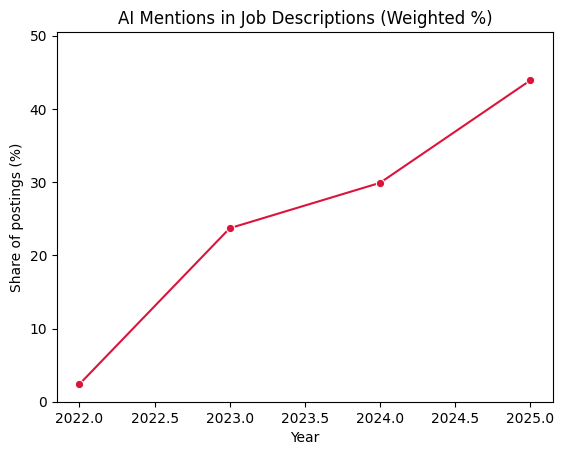

In [83]:
sns.lineplot(data=ai_YoY_weighted, x='listed_year', y='ai_share_weighted', marker='o', color='crimson')
plt.title('AI Mentions in Job Descriptions (Weighted %)')
plt.xlabel('Year'); plt.ylabel('Share of postings (%)')
plt.ylim(0, max(5, ai_YoY_weighted['ai_share_weighted'].max()*1.15))
plt.show()

### AI Share by Role and Year (weighted)

/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/4173800904.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_merged


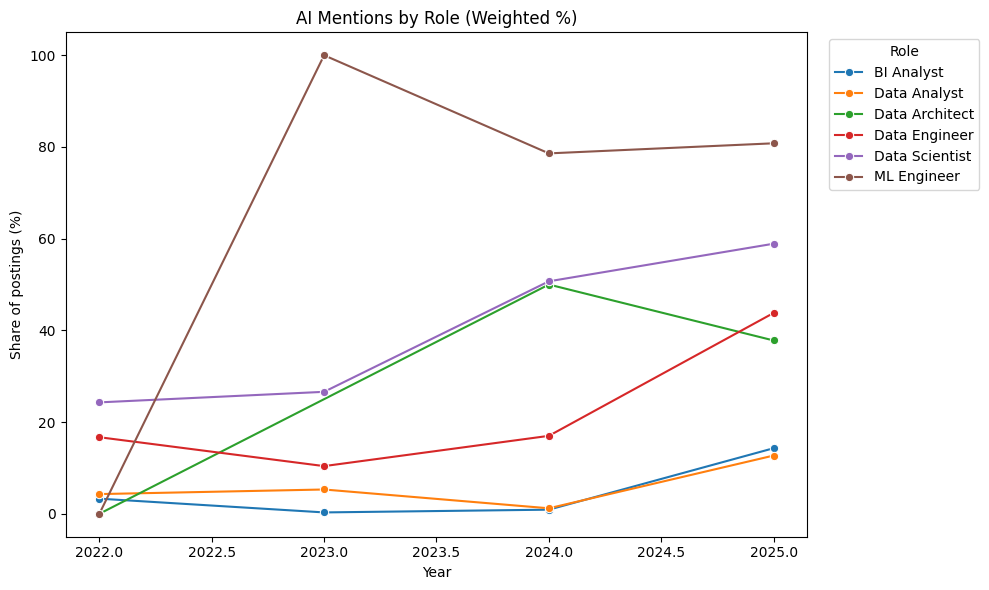

In [84]:
ai_role_yoy_w = (
    df_merged
      .groupby(['listed_year','job_basket'])
      .apply(lambda g: np.average(g['contains_ai'], weights=g['effective_weight']))
      .reset_index(name='ai_share_w')
)
ai_role_yoy_w['ai_share_w'] = (ai_role_yoy_w['ai_share_w']*100).round(1)

# Multi-line view
plt.figure(figsize=(10,6))
sns.lineplot(data=ai_role_yoy_w, x='listed_year', y='ai_share_w', hue='job_basket', marker='o')
plt.title('AI Mentions by Role (Weighted %)')
plt.xlabel('Year'); plt.ylabel('Share of postings (%)')
plt.legend(title='Role', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

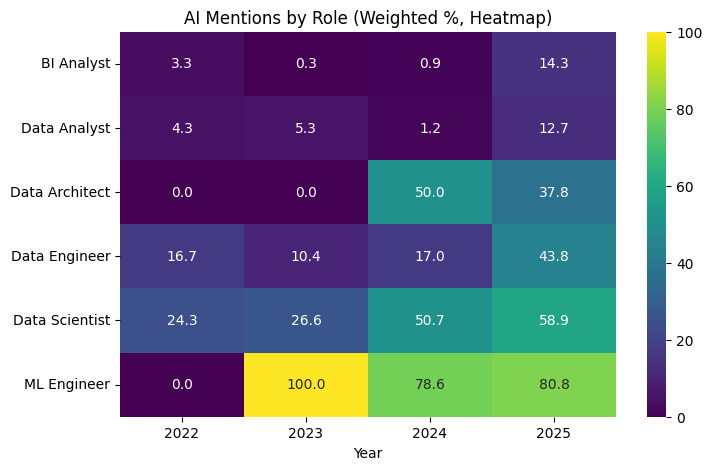

In [85]:
# Heat map
pivot_ai = ai_role_yoy_w.pivot(index='job_basket', columns='listed_year', values='ai_share_w').fillna(0)
plt.figure(figsize=(8,5))
sns.heatmap(pivot_ai, annot=True, fmt='.1f', cmap='viridis')
plt.title('AI Mentions by Role (Weighted %, Heatmap)')
plt.xlabel('Year'); plt.ylabel('')
plt.show()

### Inflection Point for AI

In [86]:
# First year where AI share exceeds a small threshold (e.g., 5%) arbiterary
thr = 5.0

overall_inflection = (
    ai_YoY_weighted.sort_values('listed_year')
            .query('ai_share_weighted >= @thr')
            .head(1)['listed_year']
            .squeeze()
    if (ai_YoY_weighted['ai_share_weighted'] >= thr).any() else None
)

role_inflection = (
    ai_role_yoy_w
      .sort_values(['job_basket','listed_year'])
      .groupby('job_basket')
      .apply(lambda d: d.loc[d['ai_share_w'] >= thr, 'listed_year'].min())
      .rename('first_year_ge_5pct')
      .reset_index()
)

display(overall_inflection)
display(role_inflection.sort_values('first_year_ge_5pct'))

/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/294127636.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ai_role_yoy_w


np.int64(2023)

,job_basket,first_year_ge_5pct
3,Data Engineer,2022
4,Data Scientist,2022
1,Data Analyst,2023
5,ML Engineer,2023
2,Data Architect,2024
0,BI Analyst,2025


### 2025 Snapshot [Ranked roles by AI adoption]

In [87]:
ai_2025 = (ai_role_yoy_w.query('listed_year == 2025')
           .sort_values('ai_share_w', ascending=False))
display(ai_2025)

,listed_year,job_basket,ai_share_w
22,2025,ML Engineer,80.8
21,2025,Data Scientist,58.9
20,2025,Data Engineer,43.8
19,2025,Data Architect,37.8
17,2025,BI Analyst,14.3
18,2025,Data Analyst,12.7


##### Notes
	•	Weighting: All AI rates are weighted by effective_weight so years/sources with heavy scraping don’t dominate.

	•	Signal term set: Uses your contains_ai regex (AI / GenAI / LLM / “AI-powered/driven” etc.).

	•	Inflection point: We mark the first year ≥ 5% to show when AI language became mainstream in postings.
    
	•	Role lens: The line + heatmap views reveal which roles absorb AI language fastest.

# KPI 4

### Skills Shift over time

In [88]:
skills = ['SQL','Python','Excel','Tableau','Power BI','Cloud']

m = (
    df_merged
      .assign(weight=df_merged['effective_weight'])
      .melt(id_vars=['listed_year','weight'],
            value_vars=skills, var_name='skill', value_name='present')
)

skill_share = (
    m.assign(present=m['present'].fillna(0).astype(int))
     .groupby(['listed_year','skill'])
     .apply(lambda g: np.average(g['present'], weights=g['weight']))
     .reset_index(name='skill_share')
)

skill_share['skill_share'] = (skill_share['skill_share'] * 100).round(1)
skill_share.sort_values(['listed_year','skill'])

/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/3699764722.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  m.assign(present=m['present'].fillna(0).astype(int))


,listed_year,skill,skill_share
0,2022,Cloud,12.2
1,2022,Excel,23.1
2,2022,Power BI,17.0
3,2022,Python,21.8
4,2022,SQL,83.2
5,2022,Tableau,21.3
6,2023,Cloud,24.2
7,2023,Excel,22.2
8,2023,Power BI,39.8
9,2023,Python,53.1


### Top 5 skills

In [89]:
top_skills_per_year = (
    skill_share
    .sort_values(['listed_year','skill_share'], ascending=[True,False])
    .groupby('listed_year')
    .head(10)   # top 10 per year
)

display(top_skills_per_year)

,listed_year,skill,skill_share
4,2022,SQL,83.2
1,2022,Excel,23.1
3,2022,Python,21.8
5,2022,Tableau,21.3
2,2022,Power BI,17.0
0,2022,Cloud,12.2
9,2023,Python,53.1
11,2023,Tableau,43.5
10,2023,SQL,40.5
8,2023,Power BI,39.8


### Visuals

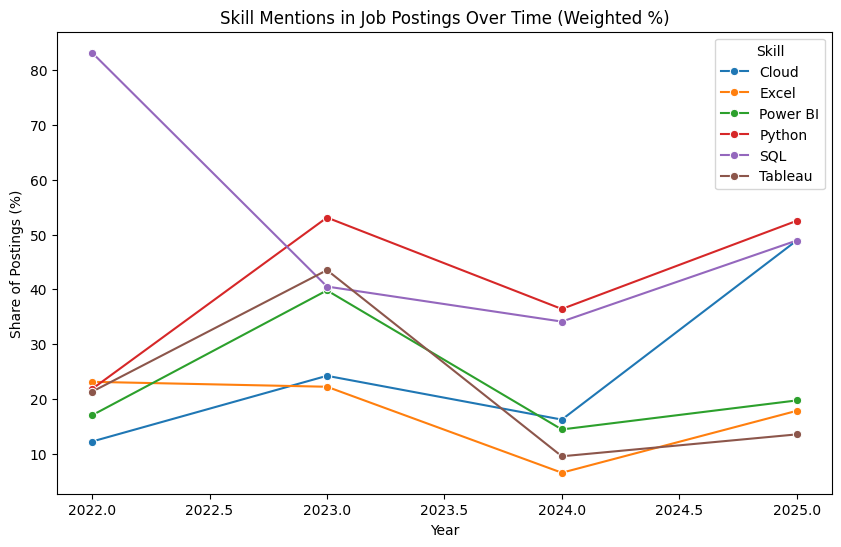

In [90]:
# Trend Lines YoY
plt.figure(figsize=(10,6))
sns.lineplot(
    data=skill_share, 
    x='listed_year', y='skill_share', 
    hue='skill', marker='o'
)
plt.title("Skill Mentions in Job Postings Over Time (Weighted %)")
plt.xlabel("Year")
plt.ylabel("Share of Postings (%)")
plt.legend(title="Skill")
plt.show()

### Heat Map of Skill for each year

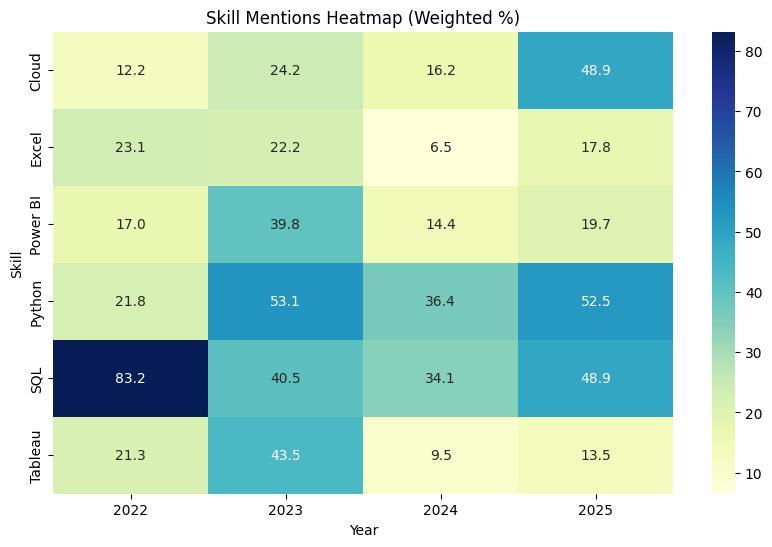

In [91]:
pivot_skills = skill_share.pivot(index="skill", columns="listed_year", values="skill_share")

plt.figure(figsize=(10,6))
sns.heatmap(pivot_skills, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Skill Mentions Heatmap (Weighted %)")
plt.xlabel("Year")
plt.ylabel("Skill")
plt.show()

### Top 3 year snapshot


In [92]:
top3_per_year = (
    skill_share.groupby('listed_year')
    .apply(lambda g: g.nlargest(3, 'skill_share', 'all'))
    .reset_index(drop=True)
)

print("Top 3 Skills per Year (Weighted %)")
display(top3_per_year)

Top 3 Skills per Year (Weighted %)


/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/2852416357.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  skill_share.groupby('listed_year')


,listed_year,skill,skill_share
0,2022,SQL,83.2
1,2022,Excel,23.1
2,2022,Python,21.8
3,2023,Python,53.1
4,2023,Tableau,43.5
5,2023,SQL,40.5
6,2024,Python,36.4
7,2024,SQL,34.1
8,2024,Cloud,16.2
9,2025,Python,52.5


## KPI 5

### Remote and AI words in job descriptions

In [93]:
df_merged['work_type'] = np.where(df_merged['isremote'],'Remote','Onsite')

### Line plot for the above calculations

In [94]:
ai_remote_yoy_w = (
df_merged
.groupby(['listed_year','work_type'])
.apply(lambda g: weighted_mean(g,'contains_ai'))
.reset_index(name='ai_share_w')
)
ai_remote_yoy_w['ai_share_w'] = (ai_remote_yoy_w['ai_share_w']*100).round(1)
ai_remote_yoy_w.sort_values(['listed_year','work_type'], inplace=True)
display(ai_remote_yoy_w)

/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/1321749190.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_merged


,listed_year,work_type,ai_share_w
0,2022,Onsite,1.8
1,2022,Remote,4.6
2,2023,Onsite,29.8
3,2023,Remote,7.5
4,2024,Onsite,25.4
5,2024,Remote,55.8
6,2025,Onsite,43.2
7,2025,Remote,50.0


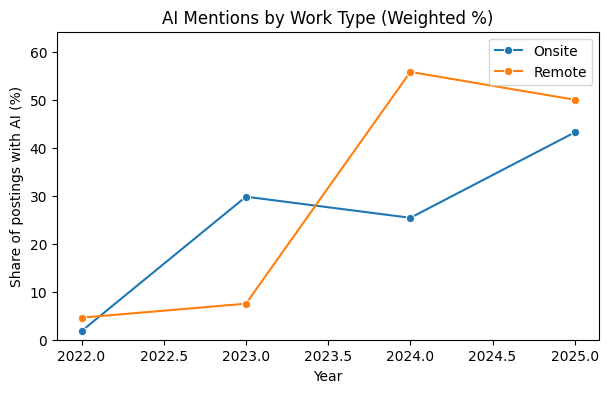

In [95]:
plt.figure(figsize=(7,4))
sns.lineplot(data=ai_remote_yoy_w, x='listed_year', y='ai_share_w', hue='work_type', marker='o')
plt.title('AI Mentions by Work Type (Weighted %)')
plt.xlabel('Year'); plt.ylabel('Share of postings with AI (%)')
plt.ylim(0, max(5, ai_remote_yoy_w['ai_share_w'].max()*1.15))
plt.legend(title='')
plt.show()

### By role 

/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/935401197.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_merged


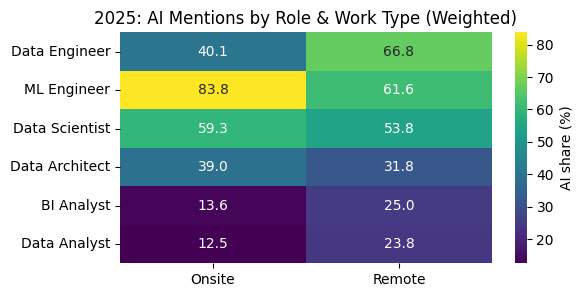

In [96]:
ai_role_remote_w = (
    df_merged
      .groupby(['listed_year','job_basket','work_type'])
      .apply(lambda g: weighted_mean(g,'contains_ai'))
      .reset_index(name='ai_share_w')
)
ai_role_remote_w['ai_share_w'] = (ai_role_remote_w['ai_share_w']*100).round(1)

# 2025 heatmap
hm_2025 = (ai_role_remote_w.query('listed_year==2025')
           .pivot(index='job_basket', columns='work_type', values='ai_share_w')
           .fillna(0).sort_values('Remote', ascending=False))

plt.figure(figsize=(6, max(3, 0.4*len(hm_2025))))
sns.heatmap(hm_2025, annot=True, fmt='.1f', cmap='viridis', cbar_kws={'label':'AI share (%)'})
plt.title('2025: AI Mentions by Role & Work Type (Weighted)')
plt.xlabel(''); plt.ylabel('')
plt.show()

# KPI 6

### Company level insights

In [97]:
dfc = df_merged.copy()

# basic trim + collapse whitespace
dfc['company_clean'] = (
    dfc['company_name']
      .fillna('Unknown')
      .str.strip()
      .str.replace(r'\s+', ' ', regex=True)
)

# strip common legal suffixes for grouping (Inc, LLC, Ltd, Corp…)
legal_suffix_pattern = (
    r'(?i)\b('
    r'incorporated|inc\.?|ltd\.?|limited|corp\.?|corporation|llc|llp|lp|ulc|'
    r'company|co\.?|gmbh|bv|sas|sarl|plc|ag|pte\.?\s*ltd\.?|pte\.?|s\.?a\.?'
    r')\b\.?'
)
dfc['company_group'] = (
    dfc['company_clean']
      .str.replace(legal_suffix_pattern, '', regex=True)
      .str.replace(r'[^\w&\-\s]', '', regex=True) # remove punctuation
      .str.replace(r'\s+', ' ', regex=True)
      .str.strip()
      .str.title()
)

# If you maintain a manual alias map, apply it here (optional)
alias_map = {
    # "Jpmorgan Chase": "JPMorgan Chase",
    # "Microsoft Corp": "Microsoft",
}
dfc['company_group'] = dfc['company_group'].replace(alias_map)

### Top Employer per year

In [98]:
# Company grouping
company_map = {
    # Amazon
    'Amazon': 'Amazon', 'Amazon Web Services': 'Amazon',
    'Amazon Development Center Us': 'Amazon',
    'Amazon Development Centre Canada': 'Amazon',
    'Amazon Web Services Aws': 'Amazon',
    'Amazon Web Services Canada': 'Amazon',
    'Amazon Data Services': 'Amazon',
    
    # Apple
    'Apple': 'Apple', 'Apple Bank For Savings': 'Apple',
    
    # Google
    'Google': 'Google',
    
    # Meta
    'Meta': 'Meta', 'Meta Force Technology Staffing': 'Meta',
    
    # Microsoft
    'Microsoft': 'Microsoft',
    
    # Deloitte
    'Deloitte': 'Deloitte', 'Deloitte Consulting': 'Deloitte',
    
    # PwC
    'Pwc': 'PwC', 'Pwc Canada': 'PwC',
    
    # Accenture
    'Accenture': 'Accenture',
    'Accenture Federal Services': 'Accenture',
    'Accenture Federal Services - National Security Portfolio': 'Accenture',
    
    # Capgemini
    'Capgemini': 'Capgemini',
    'Capgemini Government Solutions': 'Capgemini',
    'Capgemini Invent': 'Capgemini',
    
    # KPMG
    'Kpmg': 'KPMG', 'Kpmg Us': 'KPMG',
    
    # IBM
    'Ibm': 'IBM'
}

# Apply mapping
df_merged['company_grouped'] = df_merged['company_name'].map(company_map).fillna(df_merged['company_name'])

/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/502738902.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_merged.query("company_grouped in ['Amazon','Apple','Google','Meta','Microsoft','Deloitte','PwC','Accenture','Capgemini','KPMG','IBM']")


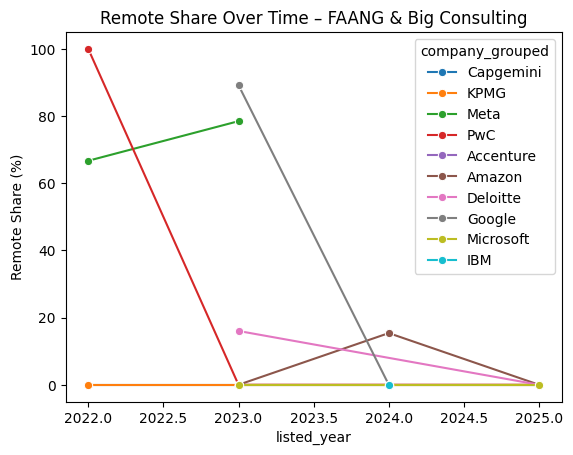

In [99]:
remote_faang = (
    df_merged.query("company_grouped in ['Amazon','Apple','Google','Meta','Microsoft','Deloitte','PwC','Accenture','Capgemini','KPMG','IBM']")
    .groupby(['listed_year','company_grouped'])
    .apply(lambda g: np.average(g['isremote'], weights=g['effective_weight']))
    .reset_index(name='remote_share')
)

remote_faang['remote_share'] *= 100

sns.lineplot(data=remote_faang, x='listed_year', y='remote_share', hue='company_grouped', marker='o')
plt.title("Remote Share Over Time – FAANG & Big Consulting")
plt.ylabel("Remote Share (%)")
plt.show()

#### updating the growth_role_yoy for years later than the base year

In [100]:
growth_role_yoy_update=growth_role_yoy.query("listed_year >2022")
growth_role_yoy_update['yoy_growth_%'] = growth_role_yoy_update['yoy_growth_%'].clip(lower=-100,upper=200)

/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/1274518102.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  growth_role_yoy_update['yoy_growth_%'] = growth_role_yoy_update['yoy_growth_%'].clip(lower=-100,upper=200)


### Enriching the Clould Tech for bashboard

In [101]:
import ast
# Not Normalized
# Step 1: ensure Cloud_list is actually a Python list, not a string
# (only needed if your column looks like "['aws','docker']" instead of real lists)
df_merged['Cloud_list'] = df_merged['Cloud_list'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Step 2: explode into one row per skill
cloud_long = (
    df_merged[['listed_year','effective_weight','Cloud_list']]
      .explode('Cloud_list')
      .dropna(subset=['Cloud_list'])
      .rename(columns={'Cloud_list': 'skill'})
)

# Step 3: denominator (total weight per year)
year_den = (
    df_merged.groupby('listed_year', as_index=False)['effective_weight']
             .sum()
             .rename(columns={'effective_weight':'year_weight'})
)

# Step 4: numerator (sum of weights per year+skill)
cloud_num = (
    cloud_long.groupby(['listed_year','skill'], as_index=False)['effective_weight']
              .sum()
              .rename(columns={'effective_weight':'skill_weight'})
)

# Step 5: merge & compute share
cloud_share = (
    cloud_num.merge(year_den, on='listed_year', how='left')
             .assign(skill_share=lambda d: (d['skill_weight']/d['year_weight']*100).round(1))
             .sort_values(['listed_year','skill'])
)

cloud_share

,listed_year,skill,skill_weight,year_weight,skill_share
0,2022,airflow,0.013371,2.0,0.7
1,2022,aws,0.082336,2.0,4.1
2,2022,azure,0.054891,2.0,2.7
3,2022,bigquery,0.012667,2.0,0.6
4,2022,databricks,0.022519,2.0,1.1
5,2022,dbt,0.016890,2.0,0.8
6,2022,docker,0.007037,2.0,0.4
7,2022,gcp,0.042224,2.0,2.1
8,2022,kafka,0.009852,2.0,0.5
9,2022,kubernetes,0.006334,2.0,0.3


In [102]:
# Normalized
# Step 1: ensure Cloud_list is actually a Python list, not a string
# (only needed if your column looks like "['aws','docker']" instead of real lists)
df_merged['Cloud_list'] = df_merged['Cloud_list'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Step 2: explode into one row per skill
cloud_long_norm = (
    df_merged[['listed_year','effective_weight','Cloud_list']]
      .explode('Cloud_list')
      .dropna(subset=['Cloud_list'])
      .rename(columns={'Cloud_list':'skill'})
)

# distribute weight evenly across tools in the same posting
cloud_long_norm['tool_count'] = cloud_long_norm.groupby(level=0)['skill'].transform('count')
cloud_long_norm['adj_weight'] = cloud_long_norm['effective_weight'] / cloud_long_norm['tool_count']

# Step 3: denominator (total weight per year)
year_den_norm = (
    df_merged.groupby('listed_year', as_index=False)['effective_weight']
             .sum()
             .rename(columns={'effective_weight':'year_weight'})
)

# Step 4: numerator (sum of weights per year+skill)
cloud_num_norm = (
    cloud_long_norm.groupby(['listed_year','skill'], as_index=False)['adj_weight']
              .sum()
              .rename(columns={'adj_weight':'skill_weight'})
)

# Step 5: merge & compute share
cloud_share_norm = (
    cloud_num_norm.merge(year_den, on='listed_year', how='left')
             .assign(skill_share=lambda d: (d['skill_weight']/d['year_weight']*100).round(1))
             .sort_values(['listed_year','skill'])
)

cloud_share_norm

,listed_year,skill,skill_weight,year_weight,skill_share
0,2022,airflow,0.005033,2.0,0.3
1,2022,aws,0.040490,2.0,2.0
2,2022,azure,0.028971,2.0,1.4
3,2022,bigquery,0.004476,2.0,0.2
4,2022,databricks,0.011271,2.0,0.6
5,2022,dbt,0.008198,2.0,0.4
6,2022,docker,0.002541,2.0,0.1
7,2022,gcp,0.021671,2.0,1.1
8,2022,kafka,0.005026,2.0,0.3
9,2022,kubernetes,0.001919,2.0,0.1


### where were the most jobs posted

In [103]:
df_merged.head(3)

,title,company_name,job_location,via,description,extensions,description_tokens,job_basket,listed_time,location_bucket,...,comp_type,source_file,listed_year,weights,contains_ai,seniority_group,isremote,effective_weight,work_type,company_grouped
0,Data Analyst Sr,CalOptima,United States,via WayUp,WHY CALOPTIMA? CalOptima is the single largest...,"['1 hour ago', 'Full-time']","['tableau', 'spreadsheet', 'word', 'visual_bas...",Data Analyst,2025.0,United States,...,salary,gsearch_jobs_2023_q1.csv,2023,0.090458,False,Executive,False,0.000377,Onsite,CalOptima
1,"Data Analyst, Space Operations Data",Virgin Galactic,United States,via Virgin Galactic Careers,As an Operations Data Analyst you will support...,"['1 hour ago', 'Full-time', 'Health insurance']","['power_bi', 'excel']",Data Analyst,2025.0,United States,...,salary,gsearch_jobs_2023_q1.csv,2023,0.090458,True,Mid,False,0.000377,Onsite,Virgin Galactic
3,Senior Business Data Analyst,U.S. Bank,"Oklahoma City, OK",via My Stateline Jobs,"At U.S. Bank, we're passionate about helping c...","['1 hour ago', 'Full-time', 'Health insurance']",[],Data Analyst,2025.0,United States,...,salary,gsearch_jobs_2023_q1.csv,2023,0.090458,False,Senior,False,0.000377,Onsite,U.S. Bank


### Additional KPIs of Via i.e. where jobs were posted

In [104]:
posting_sources = (
    df_merged
      .groupby(['listed_year','via'], as_index=False)
      .agg(
          count_posting=('via','count'),                      # raw postings
          weighted_posts=('effective_weight','sum')           # weighted postings
      )
)

# normalize within year for % share
posting_sources['year_total'] = posting_sources.groupby('listed_year')['weighted_posts'].transform('sum')
posting_sources['share_in_year_%'] = (
    posting_sources['weighted_posts'] / posting_sources['year_total'] * 100
).round(1)

posting_sources

,listed_year,via,count_posting,weighted_posts,year_total,share_in_year_%
0,2022,indeed,1,1.000000,2.000000,50.0
1,2022,via Adzuna,37,0.026038,2.000000,1.3
2,2022,via Ai-Jobs.net,6,0.004222,2.000000,0.2
3,2022,via AngelList,1,0.000704,2.000000,0.0
4,2022,via AngelList Talent,2,0.001407,2.000000,0.1
...,...,...,...,...,...,...
519,2024,www.usajobs.gov,2,0.006734,9.858586,0.1
520,2024,www.vailhealth.org,1,0.003367,9.858586,0.0
521,2024,www.zocdoc.com,1,0.003367,9.858586,0.0
522,2024,www.zoominfo.com,1,0.003367,9.858586,0.0


In [105]:
# clean sort + filter
posting_sources = posting_sources.sort_values(['listed_year','share_in_year_%'], ascending=[False,False])
posting_sources = posting_sources.query("count_posting > 50")
posting_sources

,listed_year,via,count_posting,weighted_posts,year_total,share_in_year_%
523,2025,indeed,1173,11.000000,11.000000,100.0
293,2023,via LinkedIn,1687,0.784036,4.998826,15.7
157,2023,via BeBee,980,0.487515,4.998826,9.8
366,2023,via Trabajo.org,709,0.333053,4.998826,6.7
406,2023,via ZipRecruiter,624,0.288865,4.998826,5.8
252,2023,via Indeed,408,0.180784,4.998826,3.6
140,2023,via Adzuna,197,0.091823,4.998826,1.8
276,2023,via Jobs Trabajo.org,102,0.059894,4.998826,1.2
355,2023,via Snagajob,144,0.062062,4.998826,1.2
161,2023,via Built In,108,0.050963,4.998826,1.0


### Saving the important KPIs to csv files

In [106]:
kpis_to_csv = {
    "remote_yoy_w": remote_yoy_w,
    "remote_role": remote_role,
    "growth_role_yoy_update": growth_role_yoy_update,
    "role_ranges": role_ranges,
    "ai_YoY_weighted": ai_YoY_weighted,
    "ai_role_yoy_w": ai_role_yoy_w,
    "pivot_ai": pivot_ai,
    "skill_share": skill_share,
    "top3_per_year": top3_per_year,
    "cloud_share": cloud_share,
    "cloud_share_norm": cloud_share_norm,
    "ai_remote_yoy_w": ai_remote_yoy_w,
    "ai_role_remote_w": ai_role_remote_w,
    "posting_sources": posting_sources
}

### looping over each file to export it to .csv format

In [107]:
# for kpis_name,kpis in kpis_to_csv.items():
#   kpis.to_csv(f"kpi_exports/{kpis_name}.csv")

In [108]:
growth_role_yoy


,listed_year,job_basket,weighted_posts,year_total,share_in_year_%,yoy_growth_%
0,2022,BI Analyst,0.042928,2.0,2.1,NaN
6,2023,BI Analyst,1.113502,5.0,22.3,2493.9
11,2024,BI Analyst,1.094276,10.0,10.9,-1.7
17,2025,BI Analyst,1.000000,11.0,9.1,-8.6
1,2022,Data Analyst,0.921886,2.0,46.1,NaN
7,2023,Data Analyst,2.729344,5.0,54.6,196.1
12,2024,Data Analyst,2.242424,10.0,22.4,-17.8
18,2025,Data Analyst,2.000000,11.0,18.2,-10.8
2,2022,Data Architect,1.000000,2.0,50.0,NaN
13,2024,Data Architect,1.000000,10.0,10.0,0.0


In [109]:
# allowing the growth rate to have 2022 year for visualization
growth_role_yoy_update2=growth_role_yoy.copy()
growth_role_yoy_update2['yoy_growth_%'] = growth_role_yoy_update2['yoy_growth_%'].clip(lower=-100,upper=200)

In [110]:
# growth_role_yoy_update2.to_csv("kpi_exports/growth_role_yo_updated2y.csv")




### Additional KPI for dashboarding

In [111]:
top3_roles = df_merged.groupby(['listed_year','job_basket'],as_index=False).agg(weighted_post = ('effective_weight','sum'))


# convert to within-year share (stable for cross-year comps even if totals vary)
top3_roles['year_total'] = top3_roles.groupby('listed_year')['weighted_post'].transform('sum')
top3_roles['share_in_year_%'] = (top3_roles['weighted_post'] / top3_roles['year_total'] * 100).round(1)

In [112]:
# Applied Ranks to each job role based on share
top3_roles['rank'] = (
    top3_roles.sort_values(['listed_year','weighted_post','job_basket'], ascending=[True,False,True])
             .groupby('listed_year')
             .cumcount() + 1
)

In [113]:
top3_roles_per_year = (
    top3_roles[top3_roles['rank'] <= 3]
      .loc[:, ['listed_year','job_basket','weighted_post','share_in_year_%','rank']]
      .sort_values(['listed_year','rank'])
)

In [114]:
top3_roles_per_year

,listed_year,job_basket,weighted_post,share_in_year_%,rank
2,2022,Data Architect,1.000000,50.0,1
1,2022,Data Analyst,0.921886,46.1,2
0,2022,BI Analyst,0.042928,2.1,3
7,2023,Data Analyst,2.729344,54.6,1
6,2023,BI Analyst,1.113502,22.3,2
10,2023,ML Engineer,1.001240,20.0,3
15,2024,Data Scientist,2.259259,22.6,1
12,2024,Data Analyst,2.242424,22.4,2
14,2024,Data Engineer,2.215488,22.2,3
18,2025,Data Analyst,2.000000,18.2,1


In [115]:
# top3_roles_per_year.to_csv('kpi_exports/top3_roles_per_year.csv')

In [116]:
ai_remote_yoy_w

,listed_year,work_type,ai_share_w
0,2022,Onsite,1.8
1,2022,Remote,4.6
2,2023,Onsite,29.8
3,2023,Remote,7.5
4,2024,Onsite,25.4
5,2024,Remote,55.8
6,2025,Onsite,43.2
7,2025,Remote,50.0


In [117]:
ai_role_remote_w

,listed_year,job_basket,work_type,ai_share_w
0,2022,BI Analyst,Onsite,9.1
1,2022,BI Analyst,Remote,2.0
2,2022,Data Analyst,Onsite,4.5
3,2022,Data Analyst,Remote,4.0
4,2022,Data Architect,Onsite,0.0
5,2022,Data Engineer,Onsite,33.3
6,2022,Data Engineer,Remote,11.1
7,2022,Data Scientist,Onsite,23.5
8,2022,Data Scientist,Remote,25.0
9,2022,ML Engineer,Remote,0.0


### Seniority Level Distribution

In [118]:
df_merged['job_basket']

0        Data Analyst
1        Data Analyst
3        Data Analyst
15       Data Analyst
18       Data Analyst
             ...     
22623     ML Engineer
22625     ML Engineer
22626     ML Engineer
22627     ML Engineer
22628     ML Engineer
Name: job_basket, Length: 9332, dtype: object

In [119]:
seniority_dist = (
    df_merged.groupby('seniority_group')
    .apply(lambda g: pd.Series({
        'avg': np.average(g['salary_mid_annual'], weights=g['effective_weight']),
        'min': g['salary_mid_annual'].min(),
        'max': g['salary_mid_annual'].max(),
        'count': g['seniority_group'].count()
    }))
    .reset_index()
    .sort_values('avg', ascending=False)
)

/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/1975714759.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_merged.groupby('seniority_group')


In [120]:
# seniority_dist.to_csv('kpi_exports/seniority_dist.csv')

### Job Basket and Salary variations

In [121]:
job_basket_salary_dist = (
    df_merged.groupby('job_basket')
    .apply(lambda g: pd.Series({
        'avg': np.average(g['salary_mid_annual'], weights=g['effective_weight']),
        'min': g['salary_mid_annual'].min(),
        'max': g['salary_mid_annual'].max(),
        'count': g['effective_weight'].sum()
    }))
    .reset_index()
    .sort_values('avg', ascending=False)
)

/var/folders/sl/2tbdr8850qq877l7gbhpjzcm0000gn/T/ipykernel_8333/2314602331.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_merged.groupby('job_basket')


In [122]:
# job_basket_salary_dist.to_csv("kpi_exports/job_basket_salary.csv")

In [123]:
posting_sources_updated = posting_sources.copy()

In [124]:
posting_sources_updated['job_basket'] = posting_sources_updated['via'].str.replace(r'via','')

In [125]:
posting_sources_updated.groupby(['listed_year','job_basket']).agg(total_posting = ('count_posting','sum')).sort_values('total_posting',ascending=False)

total_posting
listed_year job_basket                       
2023         LinkedIn                    1687
2025        indeed                       1173
2023         BeBee                        980
             Trabajo.org                  709
             ZipRecruiter                 624
2022         LinkedIn                     471
2023         Indeed                       408
             Adzuna                       197
             Snagajob                     144
             Built In                     108
             Jobs Trabajo.org             102
2022         Indeed                        84
2023         Jora                          80
             Startup Jobs                  71
2022         BeBee                         71
2023         Nexxt                         67
             SimplyHired                   62
             Monster                       54
2022         My ArkLaMiss Jobs             54
             Monster                       54

In [126]:
# posting_sources_updated.to_csv('kpi_exports/posting_updated.csv')

In [127]:
ai_remote_yoy_w

,listed_year,work_type,ai_share_w
0,2022,Onsite,1.8
1,2022,Remote,4.6
2,2023,Onsite,29.8
3,2023,Remote,7.5
4,2024,Onsite,25.4
5,2024,Remote,55.8
6,2025,Onsite,43.2
7,2025,Remote,50.0


In [128]:
seniority_dist

,seniority_group,avg,min,max,count
4,Senior,138572.178356,28525.0,327650.0,4176.0
2,Management,121636.145800,28600.0,400000.0,1009.0
1,Executive,74135.330984,28767.0,270000.0,1004.0
3,Mid,68824.263702,28000.0,250000.0,1962.0
0,Entry,59343.771670,28080.0,203060.0,477.0


### Skills per Job basket

In [148]:
df_merged.columns

Index(['title', 'company_name', 'job_location', 'via', 'description',
       'extensions', 'description_tokens', 'job_basket', 'listed_time',
       'location_bucket', 'seniority_level', 'salary_mid_annual', 'SQL',
       'Python', 'Excel', 'Tableau', 'Power BI', 'Cloud', 'Cloud_list',
       'skill_buckets', 'skill_buckets_str', 'skill_details',
       'skill_details_str', 'skills_flat', 'salary_min_annual',
       'salary_max_annual', 'salary_currency', 'comp_type', 'source_file',
       'listed_year', 'weights', 'contains_ai', 'seniority_group', 'isremote',
       'effective_weight', 'work_type', 'company_grouped'],
      dtype='object')

In [185]:
# looked for the type of this feature
print(type(df_merged['skills_flat'].iloc[0]))

<class 'str'>


In [165]:
# importing this module for converting string list into actual python list
from ast import literal_eval

In [166]:
df_c = df_merged.copy()


In [186]:
# if the each row is list then unchanged otherwise change it to list from string
df_c['skills_flat'] = df_c['skills_flat'].apply(lambda x: literal_eval(x) if isinstance(x,str) else x)

In [187]:
# explode the list
temp = df_c.explode('skills_flat',ignore_index=True).dropna(subset=['skills_flat'])

In [190]:
skill_share_per_job = ( temp.groupby(['job_basket','skills_flat'],as_index=False)['skills_flat'].size()
                       .reset_index()
)


In [191]:
skill_share_per_job

,index,job_basket,skills_flat,size
0,0,BI Analyst,Cloud,124
1,1,BI Analyst,Cloud:airflow,4
2,2,BI Analyst,Cloud:aws,33
3,3,BI Analyst,Cloud:azure,45
4,4,BI Analyst,Cloud:bigquery,7
...,...,...,...,...
111,111,ML Engineer,Excel,3
112,112,ML Engineer,Power BI,4
113,113,ML Engineer,Python,188
114,114,ML Engineer,SQL,67


In [184]:
skill_share_per_job.to_csv('kpi_exports/skill_share_per_job.csv')